This is a notebook that provides a lightweight example of patching from addition -> months.
See `cross_task_patch.py` to run this for many examples.

This notebook uses [nnsight](https://nnsight.net) for quick access to model internals.

In [1]:
from nnsight import LanguageModel 
model = LanguageModel("meta-llama/Llama-3.1-8B", dispatch=True, device_map="cuda")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [2]:
SOURCE_TASK = "addition"
TARGET_TASK = "months"
LAYER = 18 

In [3]:
import torch 
from utils import load_subspace_hf

src = load_subspace_hf(SOURCE_TASK, "output", layer=LAYER)
tgt = load_subspace_hf(TARGET_TASK, "output", layer=LAYER)
subspace, _, _ = torch.linalg.svd(torch.cat([src, tgt], dim=1), full_matrices=False)

this_proj = (subspace @ subspace.T).bfloat16()
else_proj = torch.eye(this_proj.shape[0], device=this_proj.device, dtype=this_proj.dtype) - this_proj 

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

  Subspace shape: torch.Size([4096, 16])


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

  Subspace shape: torch.Size([4096, 8])


In [4]:
from tasks import TASKS 

possible_output_tokens = []
causal_model = TASKS[TARGET_TASK]["causal_model"]
result_var = causal_model.parents["raw_output"][0]
labels = causal_model.values[result_var]
prefix = "" if TARGET_TASK in ["hours", "addition"] else " "
for l in labels:
    tid = model.tokenizer(prefix + l, add_special_tokens=False)["input_ids"][0]
    possible_output_tokens.append(tid)
possible_output_strs = [model.tokenizer.decode(t).strip() for t in possible_output_tokens]
print(possible_output_strs)

['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


In [5]:
source_prompt = "7+10="  # 17 % 12 = 5, May 
target_prompt = "Q: What month is six months after August?\nA:"

with torch.no_grad():
    # get clean probabilities 
    with model.trace(target_prompt):
        clean_probs = model.output.logits[:, -1].softmax(dim=-1).squeeze().float().save()
    
    # get source hidden state 
    with model.trace(source_prompt):
        src = model.model.layers[LAYER].output[:, -1].save()

    # get patched probs 
    with model.trace(target_prompt):
        bse = model.model.layers[LAYER].output[:, -1]
        patched = (src @ this_proj) + (bse @ else_proj)
        model.model.layers[LAYER].output[:, -1] = patched
        patched_probs = model.output.logits[:, -1].softmax(dim=-1).squeeze().float().save()

<nnsight 9206390124644685557>:5: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)


We can see that patching from `7+10=` into `What month is six months after August?` cleanly changes the month that Llama outputs. 

Because (7+10)%12=5, and May is the fifth month, the model now outputs May.

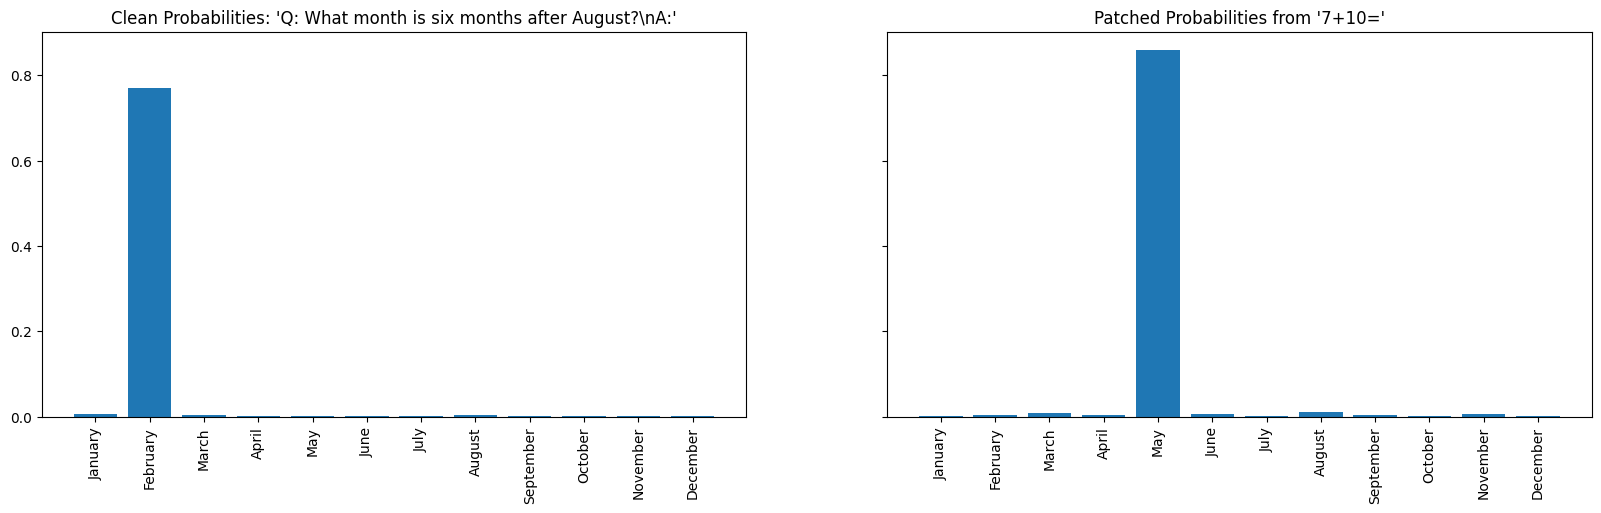

In [ ]:
# plot clean probs as a baseline on the left, then patched on the right 
import matplotlib.pyplot as plt 

fig, (ax0, ax1) = plt.subplots(ncols=2, sharey=True, figsize=(20, 5))
ax0.bar(possible_output_strs, clean_probs[(possible_output_tokens)].detach().cpu())
ax0.set_xticks(range(len(possible_output_strs)))  
ax0.set_xticklabels(possible_output_strs, rotation=90)
ax0.set_title(f"Clean Probabilities: {repr(target_prompt)}")

ax1.bar(possible_output_strs, patched_probs[(possible_output_tokens)].detach().cpu()) 
ax1.set_xticks(range(len(possible_output_strs)))  
ax1.set_xticklabels(possible_output_strs, rotation=90)
ax1.set_title(f"Patched Probabilities from {repr(source_prompt)}")

plt.show()